In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv('/content/final_data.csv')
df.head()

,Unnamed: 0,Company,Experience,Job_Post_History,Location,Ratings,Reviews,Salary,Skills,Title,URL
0,0,Accenture,5-8 Yrs,1 Day Ago,Mumbai,4.2,(30336 Reviews),Not disclosed,Due diligence,Senior Analyst-Finance Processes and Operations,https://www.naukri.com/job-listings-senior-ana...
1,1,Accenture,5-8 Yrs,1 Day Ago,Mumbai,4.2,(30336 Reviews),Not disclosed,Due diligence,Senior Analyst-Finance Processes and Operations,https://www.naukri.com/job-listings-senior-ana...
2,2,Accenture,5-8 Yrs,1 Day Ago,Mumbai,4.2,(30336 Reviews),Not disclosed,Due diligence,Senior Analyst-Finance Processes and Operations,https://www.naukri.com/job-listings-senior-ana...
3,3,Accenture,5-8 Yrs,1 Day Ago,Mumbai,4.2,(30336 Reviews),Not disclosed,Due diligence,Senior Analyst-Finance Processes and Operations,https://www.naukri.com/job-listings-senior-ana...
4,4,Accenture,5-8 Yrs,1 Day Ago,Mumbai,4.2,(30336 Reviews),Not disclosed,Due diligence,Senior Analyst-Finance Processes and Operations,https://www.naukri.com/job-listings-senior-ana...


In [2]:
df.shape

(560, 11)

In [3]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560 entries, 0 to 559
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        560 non-null    int64  
 1   Company           560 non-null    object 
 2   Experience        560 non-null    object 
 3   Job_Post_History  560 non-null    object 
 4   Location          560 non-null    object 
 5   Ratings           560 non-null    float64
 6   Reviews           560 non-null    object 
 7   Salary            560 non-null    object 
 8   Skills            560 non-null    object 
 9   Title             560 non-null    object 
 10  URL               560 non-null    object 
dtypes: float64(1), int64(1), object(9)
memory usage: 48.3+ KB
None


In [4]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Unnamed: 0          0
Company             0
Experience          0
Job_Post_History    0
Location            0
Ratings             0
Reviews             0
Salary              0
Skills              0
Title               0
URL                 0
dtype: int64


In [5]:
print("\nSummary Statistics:")
print(df.describe(include='all'))


Summary Statistics:
        Unnamed: 0    Company Experience Job_Post_History Location  \
count   560.000000        560        560              560      560   
unique         NaN         28         20               10       11   
top            NaN  Accenture    3-5 Yrs        1 Day Ago     Pune   
freq           NaN        160         90              170      150   
mean    279.500000        NaN        NaN              NaN      NaN   
std     161.802349        NaN        NaN              NaN      NaN   
min       0.000000        NaN        NaN              NaN      NaN   
25%     139.750000        NaN        NaN              NaN      NaN   
50%     279.500000        NaN        NaN              NaN      NaN   
75%     419.250000        NaN        NaN              NaN      NaN   
max     559.000000        NaN        NaN              NaN      NaN   

           Ratings          Reviews         Salary              Skills  \
count   560.000000              560            560              

In [6]:
# Start cleaning the data

# 1. Drop the "Unnamed: 0" column
df_cleaned = df.drop(columns=["Unnamed: 0"])

# 2. Clean "Experience" column - extract numeric min and max experience
df_cleaned["Experience_Min"] = df["Experience"].str.extract(r'(\d+)', expand=False).astype(int)
df_cleaned["Experience_Max"] = df["Experience"].str.extract(r'-(\d+)', expand=False)
df_cleaned["Experience_Max"] = df_cleaned["Experience_Max"].fillna(df_cleaned["Experience_Min"]).astype(int)
df_cleaned["Experience_Avg"] = (df_cleaned["Experience_Min"] + df_cleaned["Experience_Max"]) / 2

# 3. Clean "Reviews" column - remove parentheses and text
df_cleaned["Reviews"] = df["Reviews"].str.extract(r'(\d+)').astype(int)
# Strip whitespace from text fields
text_columns = ["Company", "Job_Post_History", "Location", "Skills", "Title", "URL"]
df_cleaned[text_columns] = df_cleaned[text_columns].apply(lambda x: x.str.strip())

# Show the cleaned dataset's first few rows
df_cleaned.head()


,Company,Experience,Job_Post_History,Location,Ratings,Reviews,Salary,Skills,Title,URL,Experience_Min,Experience_Max,Experience_Avg
0,Accenture,5-8 Yrs,1 Day Ago,Mumbai,4.2,30336,Not disclosed,Due diligence,Senior Analyst-Finance Processes and Operations,https://www.naukri.com/job-listings-senior-ana...,5,8,6.5
1,Accenture,5-8 Yrs,1 Day Ago,Mumbai,4.2,30336,Not disclosed,Due diligence,Senior Analyst-Finance Processes and Operations,https://www.naukri.com/job-listings-senior-ana...,5,8,6.5
2,Accenture,5-8 Yrs,1 Day Ago,Mumbai,4.2,30336,Not disclosed,Due diligence,Senior Analyst-Finance Processes and Operations,https://www.naukri.com/job-listings-senior-ana...,5,8,6.5
3,Accenture,5-8 Yrs,1 Day Ago,Mumbai,4.2,30336,Not disclosed,Due diligence,Senior Analyst-Finance Processes and Operations,https://www.naukri.com/job-listings-senior-ana...,5,8,6.5
4,Accenture,5-8 Yrs,1 Day Ago,Mumbai,4.2,30336,Not disclosed,Due diligence,Senior Analyst-Finance Processes and Operations,https://www.naukri.com/job-listings-senior-ana...,5,8,6.5


In [7]:
import re
#clean the "job_post_history" colunm
def clean_job_post_history(post_history):
  if isinstance(post_history,str):
    post_history=re.sub(r'\s*Day Ago','',post_history)
    post_history=re.sub(r'\s*Days Ago','',post_history)
    post_history=re.sub(r'\s*Hour Ago','',post_history)
    post_history=re.sub(r'\s*Hours Ago','',post_history)
  return post_history if post_history else None

df_cleaned['Job_Post_History']=df_cleaned['Job_Post_History'].apply(clean_job_post_history)

In [8]:
# Cleaning salary column
def clean_salary(salary):
    if pd.isna(salary) or "Not Disclosed" in str(salary):
        return np.nan
    salary = str(salary)
    salary = salary.replace(",", '').replace("per year", "").replace("per annum", "").strip()

    if 'L' in salary:
        salary = salary.replace("L", "0000")

    numbers = re.findall(r"\d+(?:\.\d+)?", salary)

    if len(numbers) == 0:
        return np.nan

    numbers = [float(num) for num in numbers]

    if len(numbers) == 2:
        return sum(numbers) / 2

    return numbers[0]

# Apply cleaning
df_cleaned['cleaned_Salary'] = df_cleaned['Salary'].apply(clean_salary)

# Fill missing values with median of cleaned salary
df_cleaned['Cleaned_Salary'] = df_cleaned['cleaned_Salary'].fillna(df_cleaned['cleaned_Salary'].median())

# Drop the original salary column
df_cleaned = df_cleaned.drop(columns=['Salary', 'cleaned_Salary'])

df_cleaned.head()


,Company,Experience,Job_Post_History,Location,Ratings,Reviews,Skills,Title,URL,Experience_Min,Experience_Max,Experience_Avg,Cleaned_Salary
0,Accenture,5-8 Yrs,1,Mumbai,4.2,30336,Due diligence,Senior Analyst-Finance Processes and Operations,https://www.naukri.com/job-listings-senior-ana...,5,8,6.5,900000.0
1,Accenture,5-8 Yrs,1,Mumbai,4.2,30336,Due diligence,Senior Analyst-Finance Processes and Operations,https://www.naukri.com/job-listings-senior-ana...,5,8,6.5,900000.0
2,Accenture,5-8 Yrs,1,Mumbai,4.2,30336,Due diligence,Senior Analyst-Finance Processes and Operations,https://www.naukri.com/job-listings-senior-ana...,5,8,6.5,900000.0
3,Accenture,5-8 Yrs,1,Mumbai,4.2,30336,Due diligence,Senior Analyst-Finance Processes and Operations,https://www.naukri.com/job-listings-senior-ana...,5,8,6.5,900000.0
4,Accenture,5-8 Yrs,1,Mumbai,4.2,30336,Due diligence,Senior Analyst-Finance Processes and Operations,https://www.naukri.com/job-listings-senior-ana...,5,8,6.5,900000.0


In [9]:
def categorize_salary(salary):
    if pd.isna(salary):
        return 'unknown'  # for NaN salary
    elif salary < 500000:
        return 'low'
    elif salary < 1000000:
        return 'medium'
    else:
        return 'high'

# Apply to the cleaned salary column
df_cleaned['Salary_Category'] = df_cleaned['Cleaned_Salary'].apply(categorize_salary)
df_cleaned


,Company,Experience,Job_Post_History,Location,Ratings,Reviews,Skills,Title,URL,Experience_Min,Experience_Max,Experience_Avg,Cleaned_Salary,Salary_Category
0,Accenture,5-8 Yrs,1,Mumbai,4.2,30336,Due diligence,Senior Analyst-Finance Processes and Operations,https://www.naukri.com/job-listings-senior-ana...,5,8,6.5,900000.0,medium
1,Accenture,5-8 Yrs,1,Mumbai,4.2,30336,Due diligence,Senior Analyst-Finance Processes and Operations,https://www.naukri.com/job-listings-senior-ana...,5,8,6.5,900000.0,medium
2,Accenture,5-8 Yrs,1,Mumbai,4.2,30336,Due diligence,Senior Analyst-Finance Processes and Operations,https://www.naukri.com/job-listings-senior-ana...,5,8,6.5,900000.0,medium
3,Accenture,5-8 Yrs,1,Mumbai,4.2,30336,Due diligence,Senior Analyst-Finance Processes and Operations,https://www.naukri.com/job-listings-senior-ana...,5,8,6.5,900000.0,medium
4,Accenture,5-8 Yrs,1,Mumbai,4.2,30336,Due diligence,Senior Analyst-Finance Processes and Operations,https://www.naukri.com/job-listings-senior-ana...,5,8,6.5,900000.0,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,Eversendai,5-10 Yrs,1,Chennai,3.7,262,Financial reporting,Financial Analyst,https://www.naukri.com/job-listings-financial-...,5,10,7.5,1100000.0,high
556,Eversendai,5-10 Yrs,1,Chennai,3.7,262,Financial reporting,Financial Analyst,https://www.naukri.com/job-listings-financial-...,5,10,7.5,1100000.0,high
557,Eversendai,5-10 Yrs,1,Chennai,3.7,262,Financial reporting,Financial Analyst,https://www.naukri.com/job-listings-financial-...,5,10,7.5,1100000.0,high
558,Eversendai,5-10 Yrs,1,Chennai,3.7,262,Financial reporting,Financial Analyst,https://www.naukri.com/job-listings-financial-...,5,10,7.5,1100000.0,high


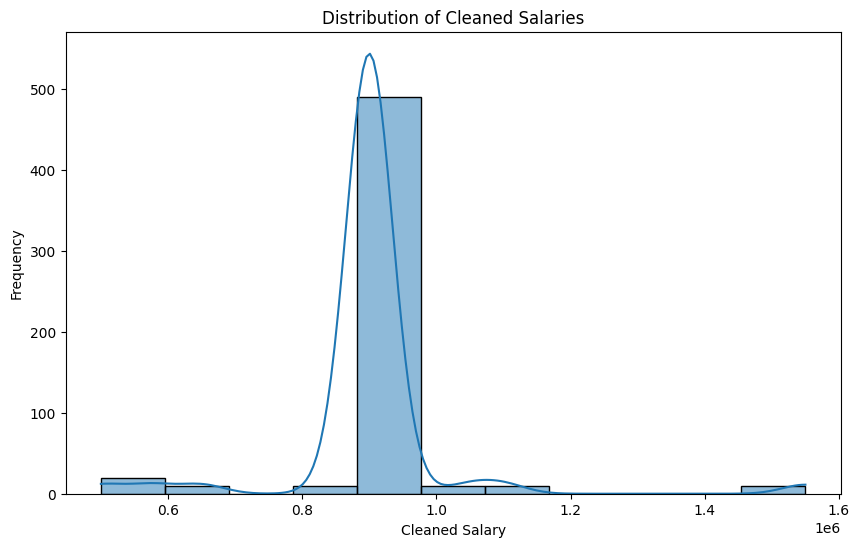

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['Cleaned_Salary'], kde=True)
plt.title('Distribution of Cleaned Salaries')
plt.xlabel('Cleaned Salary')
plt.ylabel('Frequency')
plt.show()

Text(0, 0.5, 'Cleaned Salary')

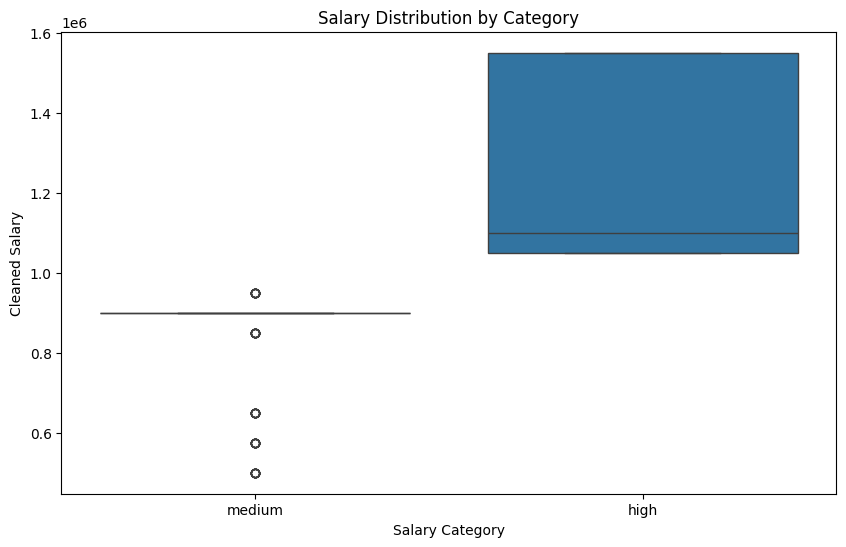

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Salary_Category', y='Cleaned_Salary', data=df_cleaned)
plt.title('Salary Distribution by Category')
plt.xlabel('Salary Category')
plt.ylabel('Cleaned Salary')

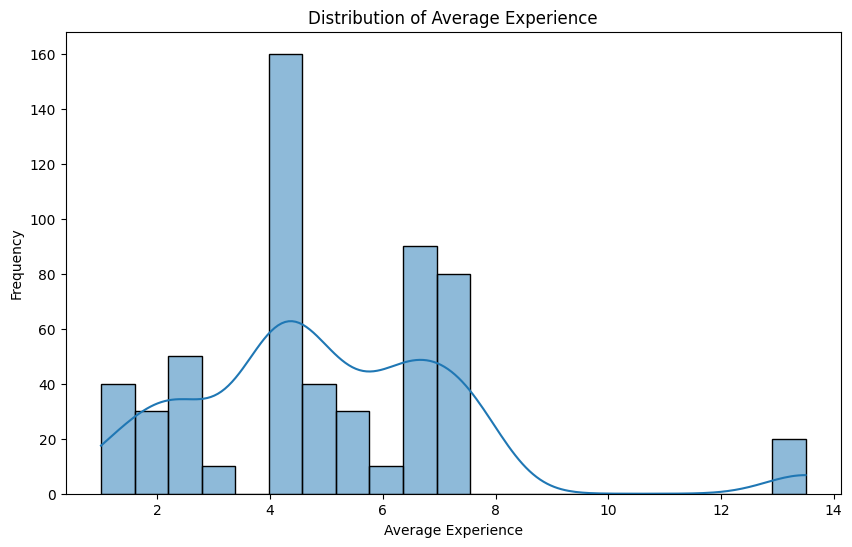

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['Experience_Avg'], kde=True)
plt.title('Distribution of Average Experience')
plt.xlabel('Average Experience')
plt.ylabel('Frequency')
plt.show()

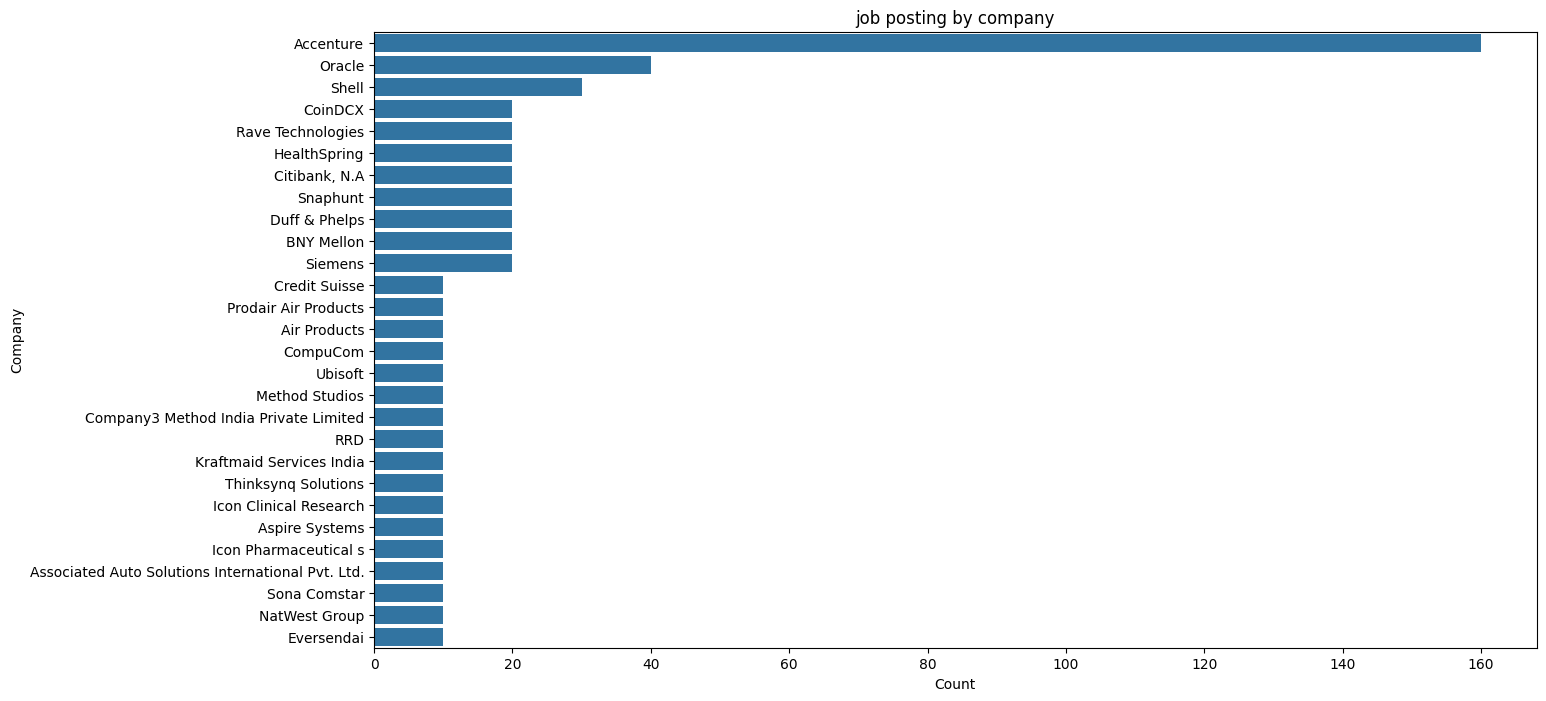

In [13]:
plt.figure(figsize=(15, 8))
sns.countplot(y='Company', data=df_cleaned,order=df_cleaned['Company'].value_counts().index)
plt.title('job posting by company')
plt.ylabel('Company')
plt.xlabel('Count')
plt.show()

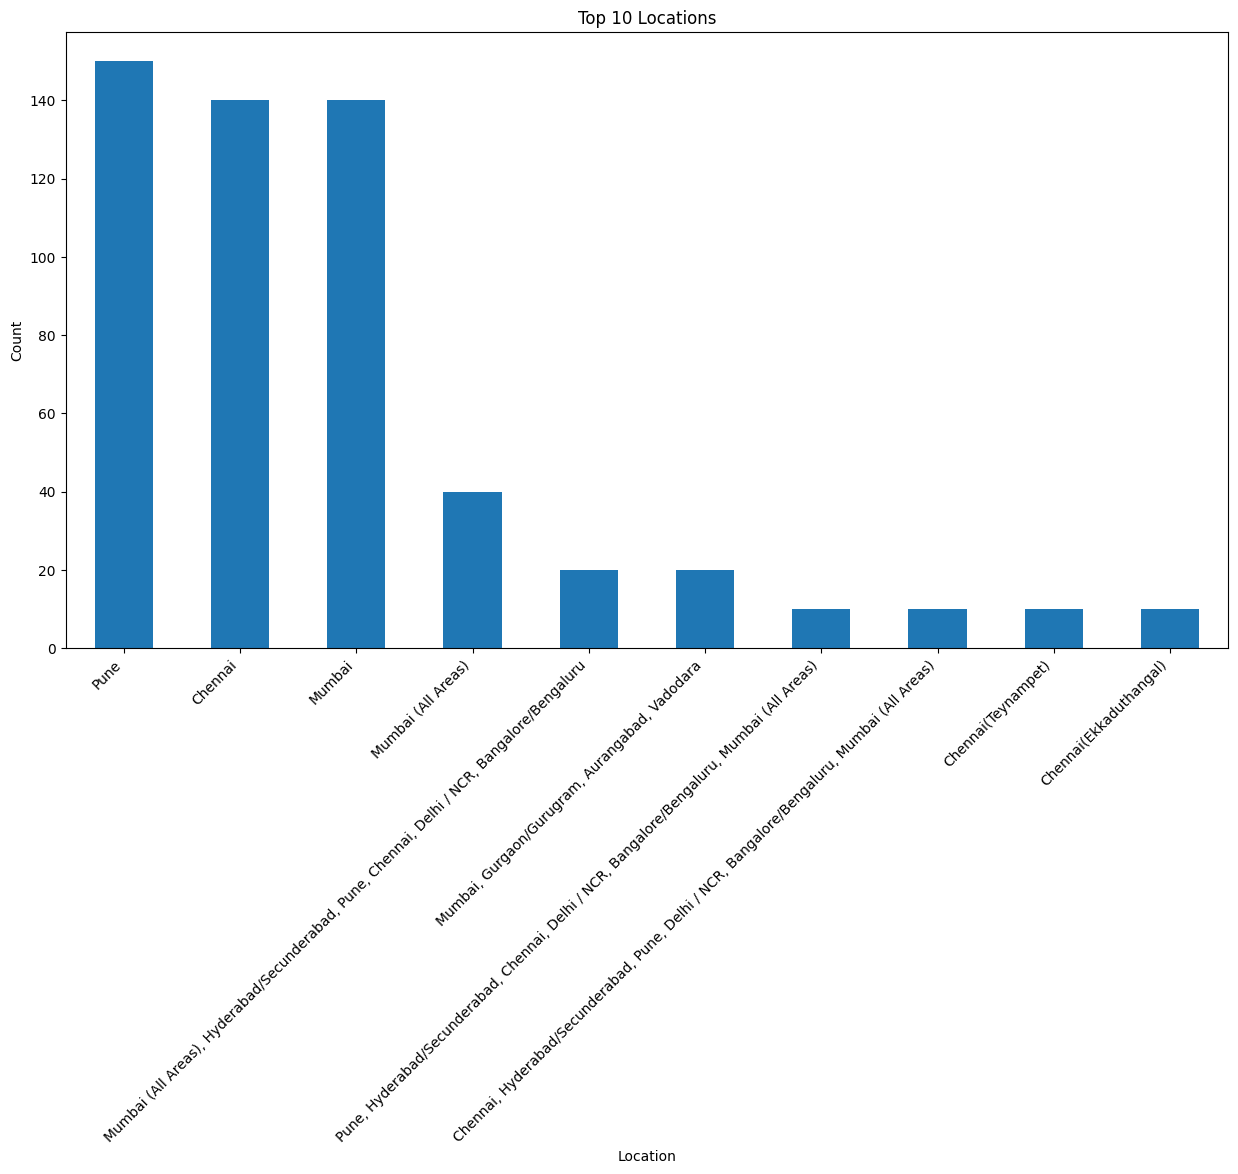

In [14]:
#count the frequency of each location
top_10_locations = df_cleaned['Location'].value_counts().head(10)
plt.figure(figsize=(15, 8))
top_10_locations.plot(kind='bar')
plt.title('Top 10 Locations')
plt.xlabel('Location')
plt.ylabel('Count')
plt.xticks(rotation=45,ha='right')
plt.show()

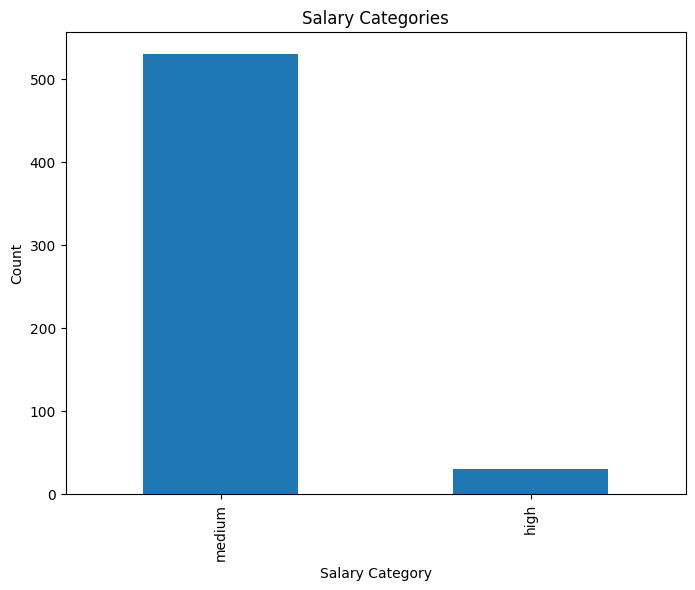

In [15]:
# salary categories
salary_categories = df_cleaned['Salary_Category'].value_counts()
plt.figure(figsize=(8, 6))
salary_categories.plot(kind='bar')
plt.title('Salary Categories')
plt.xlabel('Salary Category')
plt.ylabel('Count')
plt.show()

In [16]:
df_cleaned.columns

Index(['Company', 'Experience', 'Job_Post_History', 'Location', 'Ratings',
       'Reviews', 'Skills', 'Title', 'URL', 'Experience_Min', 'Experience_Max',
       'Experience_Avg', 'Cleaned_Salary', 'Salary_Category'],
      dtype='object')


===== Logistic Regression =====


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

Accuracy: 0.27
Classification Report:
                                                                        precision    recall  f1-score   support

                           Analyst I, Global Financial Data Operations       0.00      0.00      0.00         4
                                             Analyst-Finance Processes       0.41      1.00      0.58        14
                              Analyst-Finance Processes and Operations       0.00      0.00      0.00         1
                                            Business Analyst - Finance       0.00      0.00      0.00         4
       Business Analyst /Peoplesoft / finance modules / General ledger       0.00      0.00      0.00         1
                                                       Finance Analyst       0.09      0.23      0.12        13
                                             Finance Reporting Analyst       0.00      0.00      0.00         4
                                                     Financial An

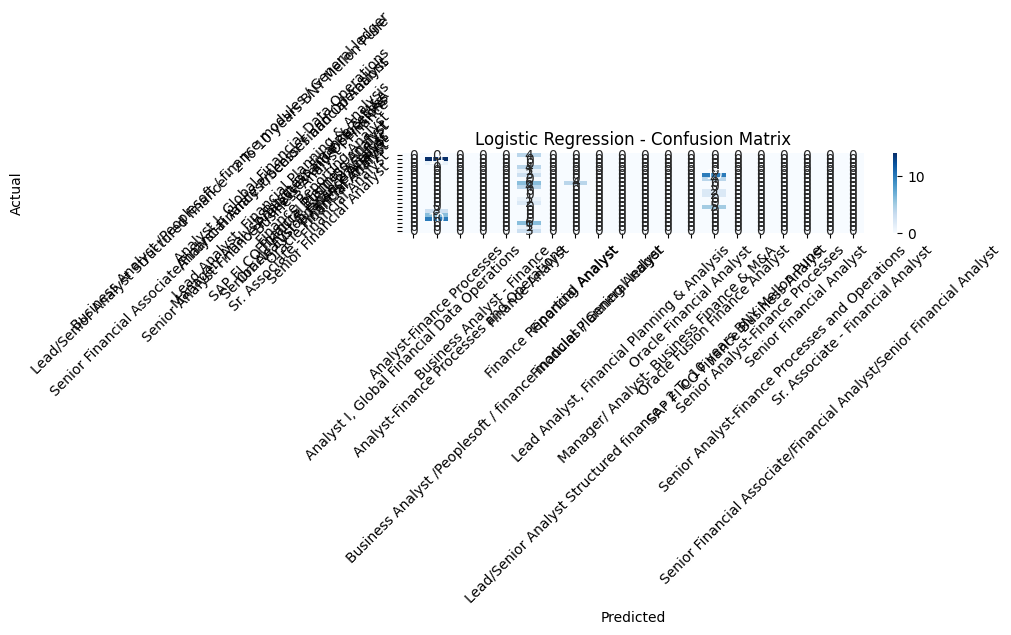


===== Random Forest =====
Accuracy: 0.96
Classification Report:
                                                                        precision    recall  f1-score   support

                           Analyst I, Global Financial Data Operations       1.00      1.00      1.00         4
                                             Analyst-Finance Processes       0.93      1.00      0.97        14
                              Analyst-Finance Processes and Operations       0.00      0.00      0.00         1
                                            Business Analyst - Finance       1.00      1.00      1.00         4
       Business Analyst /Peoplesoft / finance modules / General ledger       1.00      1.00      1.00         1
                                                       Finance Analyst       1.00      1.00      1.00        13
                                             Finance Reporting Analyst       1.00      1.00      1.00         4
                                      

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


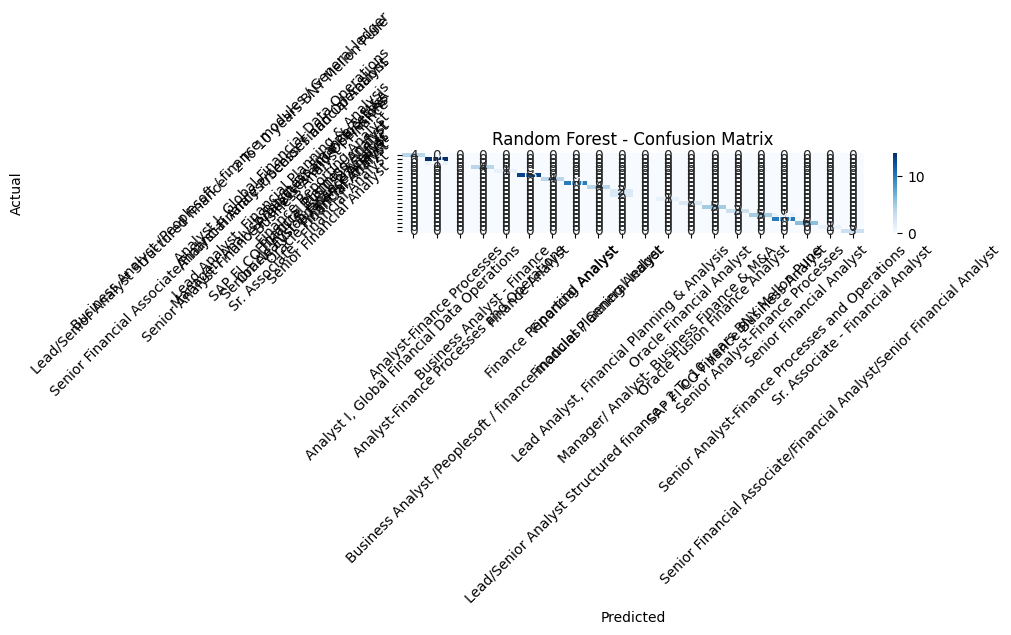


===== K-Nearest Neighbors =====
Accuracy: 0.96
Classification Report:
                                                                        precision    recall  f1-score   support

                           Analyst I, Global Financial Data Operations       1.00      1.00      1.00         4
                                             Analyst-Finance Processes       0.93      1.00      0.97        14
                              Analyst-Finance Processes and Operations       0.00      0.00      0.00         1
                                            Business Analyst - Finance       1.00      1.00      1.00         4
       Business Analyst /Peoplesoft / finance modules / General ledger       1.00      1.00      1.00         1
                                                       Finance Analyst       1.00      1.00      1.00        13
                                             Finance Reporting Analyst       1.00      1.00      1.00         4
                                

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


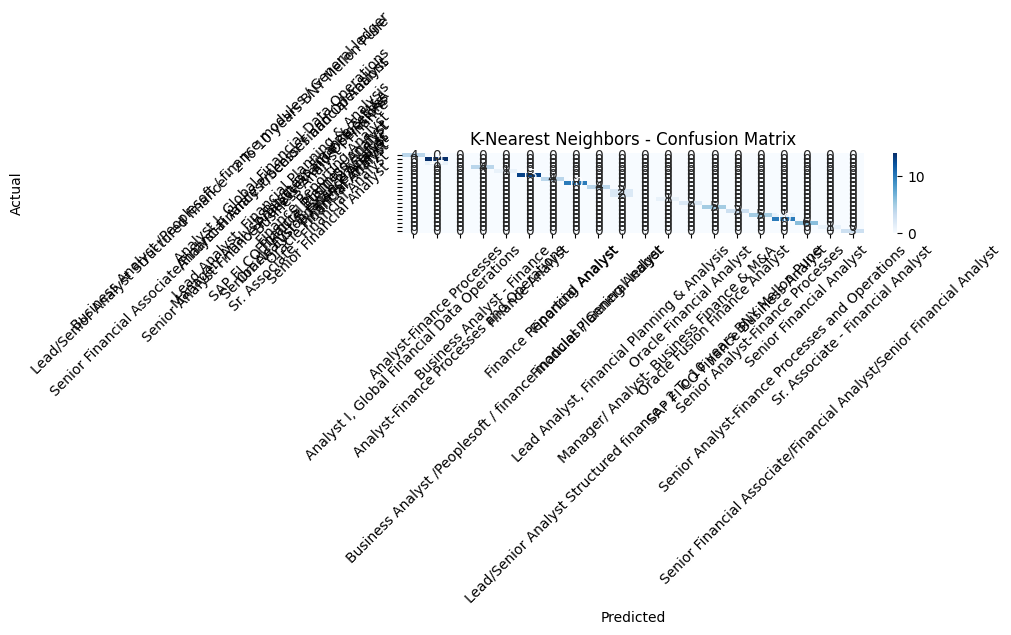


===== XGBoost =====


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:27:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.96
Classification Report:
                                                                        precision    recall  f1-score   support

                           Analyst I, Global Financial Data Operations       1.00      1.00      1.00         4
                                             Analyst-Finance Processes       0.93      1.00      0.97        14
                              Analyst-Finance Processes and Operations       0.00      0.00      0.00         1
                                            Business Analyst - Finance       1.00      1.00      1.00         4
       Business Analyst /Peoplesoft / finance modules / General ledger       1.00      1.00      1.00         1
                                                       Finance Analyst       1.00      1.00      1.00        13
                                             Finance Reporting Analyst       1.00      1.00      1.00         4
                                                     Financial An

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


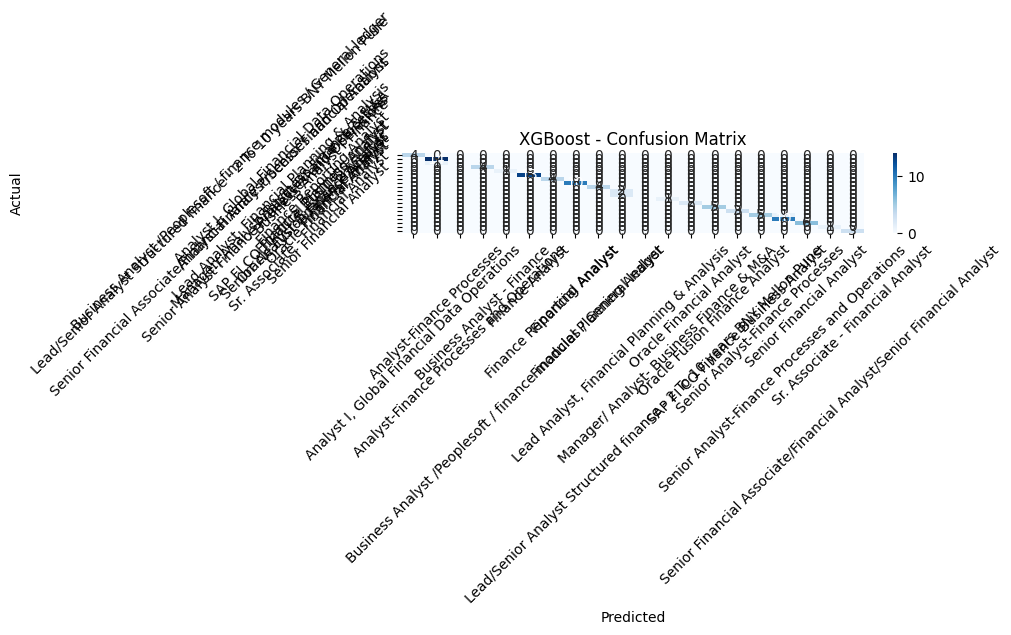

In [17]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# STEP 1: Select Features & Target
features = ['Experience_Avg', 'Reviews', 'Ratings', 'Location', 'Company', 'Salary_Category']
target = 'Title'

# STEP 2: Filter top 10 job titles and remove missing values
top_titles = df_cleaned['Title'].value_counts().nlargest(20).index
df_filtered = df_cleaned[df_cleaned['Title'].isin(top_titles)].dropna(subset=features + [target])

# STEP 3: Encode Categorical Columns
le_company = LabelEncoder()
le_location = LabelEncoder()
le_salary = LabelEncoder()
le_title = LabelEncoder()

df_filtered['Company_enc'] = le_company.fit_transform(df_filtered['Company'])
df_filtered['Location_enc'] = le_location.fit_transform(df_filtered['Location'])
df_filtered['Salary_Category_enc'] = le_salary.fit_transform(df_filtered['Salary_Category'])
df_filtered['Title_enc'] = le_title.fit_transform(df_filtered['Title'])

# STEP 4: Define features (X) and target (y)
X = df_filtered[['Experience_Avg', 'Reviews', 'Ratings', 'Company_enc', 'Location_enc', 'Salary_Category_enc']]
y = df_filtered['Title_enc']

# STEP 5: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# STEP 6: Define ML models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

# STEP 7: Train, Predict, and Evaluate each model
for name, model in models.items():
    print(f"\n===== {name} =====")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le_title.classes_))

    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=le_title.classes_, yticklabels=le_title.classes_, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{name} - Confusion Matrix')
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [19]:
# select the best model for deployment

import pickle

best_model_name = "Random Forest"
best_model = models[best_model_name]

# Save the best model using pickle
filename = 'best_job_title_prediction_model.pkl'
pickle.dump(best_model, open(filename, 'wb'))

print(f"The best model '{best_model_name}' has been saved to {filename}")

The best model 'Random Forest' has been saved to best_job_title_prediction_model.pkl


In [20]:
# prompt: cross validation

from sklearn.model_selection import cross_val_score

# Assuming X, y, and models are defined as in the original code

for name, model in models.items():
    print(f"\n===== {name} - Cross Validation =====")
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')  # 5-fold cross-validation
    print(f"Accuracy Scores (5-fold CV): {scores}")
    print(f"Mean Accuracy: {np.mean(scores):.2f}")
    print(f"Standard Deviation: {np.std(scores):.2f}")



===== Logistic Regression - Cross Validation =====


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Accuracy Scores (5-fold CV): [0.20833333 0.3125     0.25       0.29166667 0.35416667]
Mean Accuracy: 0.28
Standard Deviation: 0.05

===== Random Forest - Cross Validation =====
Accuracy Scores (5-fold CV): [0.89583333 0.89583333 0.91666667 0.95833333 0.85416667]
Mean Accuracy: 0.90
Standard Deviation: 0.03

===== K-Nearest Neighbors - Cross Validation =====
Accuracy Scores (5-fold CV): [0.95833333 0.9375     0.91666667 0.8125     0.79166667]
Mean Accuracy: 0.88
Standard Deviation: 0.07

===== XGBoost - Cross Validation =====


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:29:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:29:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:29:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:29:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy Scores (5-fold CV): [0.89583333 0.89583333 0.91666667 0.95833333 0.85416667]
Mean Accuracy: 0.90
Standard Deviation: 0.03


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:29:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [21]:
# load the saved model
!pip install joblib
import joblib
import pickle

# Load the saved model
filename = 'best_job_title_prediction_model.pkl'
loaded_model = pickle.load(open(filename, 'rb'))

In [22]:
joblib.dump(loaded_model, 'best_job_title_prediction_model.pkl')

['best_job_title_prediction_model.pkl']

In [ ]:
# prompt: create api for inference

import pickle
from flask import Flask, request, jsonify

# Load the saved model
filename = 'best_job_title_prediction_model.pkl'
loaded_model = pickle.load(open(filename, 'rb'))

# Load LabelEncoders (replace with your actual loading method)
le_company = globals().get('le_company')
le_location = globals().get('le_location')
le_salary = globals().get('le_salary')
le_title = globals().get('le_title')

app = Flask(__name__)

@app.route('/predict', methods=['POST'])
def predict_job_title():
    try:
        data = request.get_json()
        experience = float(data['experience'])
        reviews = int(data['reviews'])
        ratings = float(data['ratings'])
        company = data['company']  # Assuming 'company' is a string
        location = data['location']
        salary = data['salary']  # Assuming salary is a string

        # Preprocessing steps
        try:
            company_enc = le_company.transform([company])[0]
        except ValueError:
            company_enc = -1
        try:
            location_enc = le_location.transform([location])[0]
        except ValueError:
            location_enc = -1
        try:
            salary_enc = le_salary.transform([salary])[0]
        except ValueError:
            salary_enc = -1

        input_features = [[experience, reviews, ratings, company_enc, location_enc, salary_enc]]
        prediction = loaded_model.predict(input_features)
        predicted_job_title = le_title.inverse_transform(prediction)[0]

        return jsonify({'predicted_job_title': predicted_job_title})

    except Exception as e:
        return jsonify({'error': str(e)}), 400

if __name__ == '__main__':
    app.run(debug=True)


 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with stat
